In [21]:
import os

import torch
from torch.utils.data import DataLoader, random_split
from torch.optim import Adam
from tqdm.auto import tqdm

from copy import deepcopy

import matplotlib.pyplot as plt

import sqlite3
import pandas as pd

import subprocess
from datetime import datetime
import time

import json

import ipywidgets as widgets

from pathlib import Path
import sys

ROOT = Path.cwd().parents[1]
sys.path.append(str(ROOT))

from src.config.paths import EMBEDS_DIR, RESULTS, DB_PATH, MODELS
from src.model_selection import get_checkpoints, load_inference_models, create_model_selector
from src.fine_tune.utils import get_device

EMBED_PATH = EMBEDS_DIR/ "cont_embeds.pt"
EMBED_NAME = EMBED_PATH.stem

RESULTS_DIR = RESULTS / EMBED_NAME

MODEL_DIR = MODELS / "anomaly_head"

In [22]:
os.makedirs(MODEL_DIR, exist_ok=True)

In [23]:
DINO_DIR = MODELS / "dino_fine_tune"
CATHEAD_DIR = MODELS / "category_head"

dino_checkpoints = get_checkpoints(DINO_DIR)
cathead_checkpoints = get_checkpoints(CATHEAD_DIR)

print(f"Found {len(dino_checkpoints)} fine-tuned DINO checkpoints")
print(f"Found {len(cathead_checkpoints)} category-head checkpoints")

Found 1 fine-tuned DINO checkpoints
Found 2 category-head checkpoints


In [ ]:
selector = create_model_selector(
    dino_checkpoints=dino_checkpoints,
    category_head_checkpoints=cathead_checkpoints
)

selector.display()

Checkbox(value=False, description='Use category head')

Dropdown(description='DINO:', layout=Layout(display='', width='800px'), options=(('Select a DINO model', 'UNSE…

Dropdown(description='Category head:', layout=Layout(display='none', width='800px'), options=(('Select a categ…

Button(button_style='success', description='Confirm selection', layout=Layout(width='180px'), style=ButtonStyl…

Output()

In [26]:
device = get_device()

selected_path = selector.get_selected_path()

pipeline = load_inference_models(selected_path, device=device)

2.12.0+cu130
13.0
True
1
Device: cuda


Using cache found in /home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main


Loading DINO: /home/ciaran/Projects/bursary/UL-Summer-Bursary-2026/models/dino_fine_tune/20260731_164405/model.pt
Loading projection head: /home/ciaran/Projects/bursary/UL-Summer-Bursary-2026/models/category_head/20260801_153500/model.pt


In [27]:
conn = sqlite3.connect(DB_PATH)

df = pd.read_sql_query("""
    SELECT path, split
    FROM meta
""", conn)

categories = pd.read_sql_query("SELECT DISTINCT category FROM meta", conn)["category"].to_list()
types = pd.read_sql_query("SELECT DISTINCT type FROM meta", conn)["type"].to_list()

conn.close()

train_paths = df[df["split"] == "train"]["path"].to_list()
test_paths = df[df["split"] != "train"]["path"].to_list()

In [28]:
%load_ext autoreload 
%autoreload 2 

from src.fine_tune import ModelData, ProjectionHead, BatchSampler, NegativeSampler, contrastive_transform, test_transform
from src.fine_tune.train import train_one_epoch, evaluate
from src.fine_tune.losses.anomaly_head.combined_loss import CombinedLoss 

git_commit = subprocess.check_output( ["git", "rev-parse", "HEAD"], text=True ).strip()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
LOSSES = {
    "cont_loss" : True
}

WEIGHTS = {
  "cont_loss" : 1.0
}

NOTES = [
    "Trained using normal dino"
]

SEED = 42

NUM_WORKERS = 8
PIN_MEMORY = device.type == "cuda"
SAMPLES_PER_CATEGORY = 16

BATCH_SIZE = len(categories) * SAMPLES_PER_CATEGORY

EPOCHS = 20

DIM = 384
HIDDEN_DIM = 768

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

MODEL_NORMALISER = "layer"

MODEL_NAME = "model.pt"

In [30]:
MODEL_INFO = {
    "losses" : LOSSES,
    "weights" : WEIGHTS,
    "notes" : NOTES,
    "git_commit" : git_commit,
    "parameters" : {
        "batch_size" : BATCH_SIZE,
        "epochs" : EPOCHS,
        "samples_per_category" : SAMPLES_PER_CATEGORY,

        "model_dim" : DIM,
        "hidden_dim": HIDDEN_DIM,
        "model_normaliser": MODEL_NORMALISER,

        "learning_rate" : LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        
        "num_workers" : NUM_WORKERS,
        "pin_memory" : PIN_MEMORY,

        "random_seed" : SEED
    },
    "parent_models" : {
        stage.name: str(stage.path) if stage.path is not None else None
        for stage in pipeline
    }
}

In [31]:
category_to_id = {category: idx for idx, category in enumerate(categories)}
types_to_id = {type: idx for idx, type in enumerate(types)}

dataset = ModelData(train_paths, root=ROOT, category_to_id=category_to_id, types_to_id=None, transform=contrastive_transform)
test_set = ModelData(test_paths, root=ROOT, category_to_id=category_to_id, types_to_id=types_to_id, transform=test_transform)

train_split = int(len(dataset) * 0.95)
val_split = len(dataset) - train_split

generator = torch.Generator().manual_seed(SEED)

train_set, val_set = random_split(
    dataset,
    [train_split, val_split],
    generator=generator
)

train_labels = [dataset.category_ids[i] for i in train_set.indices]
val_labels = [dataset.category_ids[i] for i in val_set.indices]

train_sampler = BatchSampler(
    labels=train_labels,
    samples_per_cat=SAMPLES_PER_CATEGORY,
    seed=None
)

val_sampler = BatchSampler(
    labels=val_labels,
    samples_per_cat=SAMPLES_PER_CATEGORY,
    seed=SEED
)

test_labels = test_set.cat_types_ids

negative_sampler = NegativeSampler(
    labels=test_labels,
    samples_per_cat=5,
    types_to_id=types_to_id,
    seed=SEED
)

train_loader = DataLoader(
    train_set,
    batch_sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_set,
    batch_sampler=val_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

# Need to change this to remove the negative samples due to data leakage
test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

In [32]:
neg_indices = negative_sampler.get_negatives()

neg_images: list[torch.Tensor] = []
neg_labels: list[int] = []

for idx in neg_indices:
    view1, _, category_id, _ = test_set[idx]

    neg_images.append(view1)
    neg_labels.append(category_id)

neg_image_ten = torch.stack(neg_images).to(device)
neg_labels_ten = torch.tensor(
    neg_labels,
    dtype=torch.long,
    device=device
)

with torch.no_grad():
    neg_embeds: torch.Tensor = neg_image_ten
    for stage in pipeline:
        neg_embeds = stage.model(neg_embeds)

In [33]:
model = ProjectionHead(dim=DIM, hidden_dim=HIDDEN_DIM, norm_type=MODEL_NORMALISER).to(device)

optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = CombinedLoss(enabled=LOSSES, weights=WEIGHTS, negatives=neg_embeds, negative_labels=neg_labels_ten)

In [34]:
results = pd.DataFrame(columns=["epoch", "train_loss", "val_loss", "gap", "time"])

best_val = float("inf")
best_state = None

pbar = tqdm(total=EPOCHS, desc="Training")

table_out = widgets.Output()
display(table_out)

try:    
    for epoch in range(EPOCHS):
        start = time.perf_counter()

        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device, pipeline)
        val_loss = evaluate(model, val_loader, criterion, device, pipeline)

        elapsed = time.perf_counter() - start

        if val_loss < best_val:
            best_val = val_loss
            best_state = deepcopy(model.state_dict())
            
        results.loc[len(results)] = {
            "epoch": epoch+1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "gap": abs(val_loss - train_loss),
            "time": f"{elapsed:.2f}"
        }

        with table_out:
            table_out.clear_output(wait=True) # pyright: ignore[reportUnknownMemberType]
            display(results.style.hide(axis="index"))
        pbar.update(1)

finally:
    pbar.close()

    model.to("cpu")
    pipeline.to("cpu")
    
    if best_state is not None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        EXP_DIR = MODEL_DIR / timestamp

        os.makedirs(EXP_DIR, exist_ok=False)

        checkpoint = {
            "model_state_dict" : best_state,
            "parameters" : MODEL_INFO["parameters"],
            "parent_models" : MODEL_INFO["parent_models"]
        }

        torch.save(checkpoint, EXP_DIR / MODEL_NAME)

        with open(EXP_DIR / "metadata.json", "w") as f:
            json.dump(MODEL_INFO, f, indent=4)

        results.to_csv(EXP_DIR / "train_history.csv", index=False)

        print(f"Best Model Saved (val_loss={best_val:.4f})")

Training:   0%|          | 0/20 [00:00<?, ?it/s]

Output()

Best Model Saved (val_loss=3.4405)


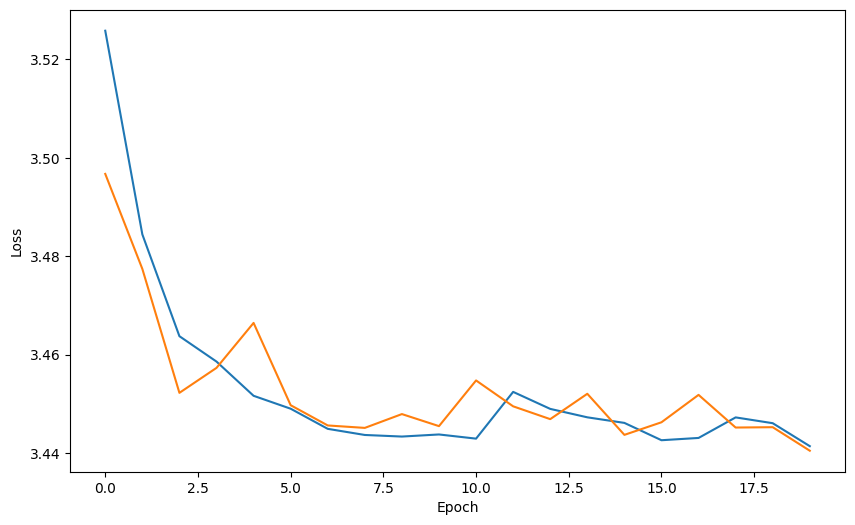

In [35]:
fig = plt.figure(figsize=(10, 6))

plt.plot(range(EPOCHS), results["train_loss"])
plt.plot(range(EPOCHS), results["val_loss"])

plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.show()